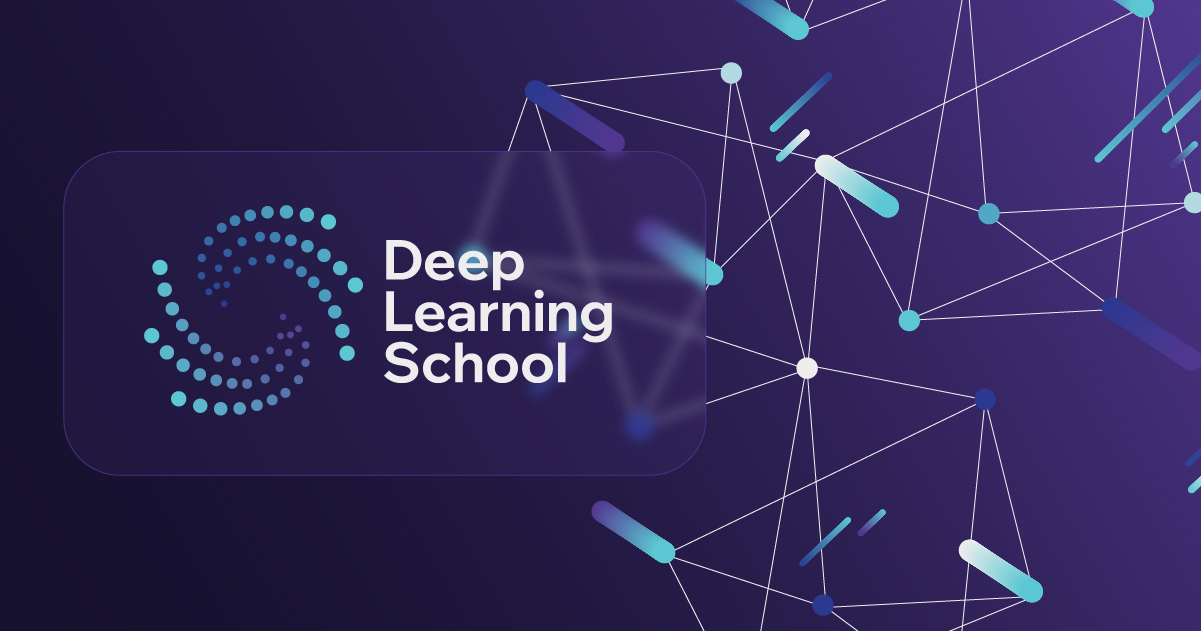


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
# !pip install kagglehub

In [2]:
import os

import imageio
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [3]:
from pathlib import Path

In [4]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


In [5]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\averkij\lfw-attributes\versions\1


In [6]:
Path(images_path)

WindowsPath('C:/Users/k142/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4')

In [7]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = Path(images_path)
ATTRIBUTES_PATH = Path(attrs_path).joinpath("lfw_attributes.txt")
# DATASET_PATH = "C:\\Users\\k142\\.cache\\kagglehub\\datasets\\jessicali9530\\lfw-dataset\\versions\\4"
# ATTRIBUTES_PATH = "C:\\Users\\k142\\.cache\\kagglehub\\datasets\\averkij\\lfw-attributes\\versions\\1\\lfw_attributes.txt"

In [8]:
df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

In [9]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids.info())
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обрезка
    # dy - количество пикселей, обрезаемых сверху и снизу
    # dx - количество пикселей, обрезаемых слева и справа
    #
    # Изменение размера
    # dimx - ширина
    # dimy - высота

    images = df['photo_path'].apply(imageio.imread) \
        .apply(lambda img: img[dy:-dy, dx:-dx]) \
        .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [10]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset(dimx=44, dimy=44)


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

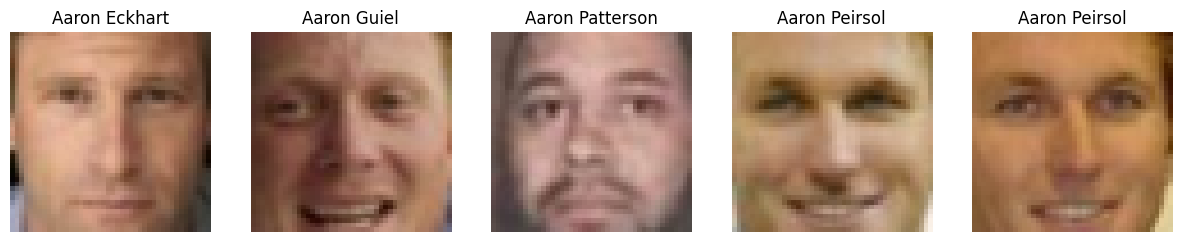

In [11]:
plt.figure(figsize=(15, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])

# plt.tight_layout()
plt.show()

In [12]:
len(images), attrs.shape[0]

(13143, 13143)

In [13]:
train_ratio = 0.8
val_ratio = 0.1
n_total = len(images)  # Общее количество данных
# test_ratio = 1 - train_ratio - val_ratio (автоматически)
ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы

train_size = int(train_ratio * n_total)
val_size = int(val_ratio * n_total)

tr, val, ts = np.split(ix, [train_size, train_size + val_size])

In [14]:
print(len(tr), len(val), len(ts))

10514 1314 1315


In [72]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms

class AutoencoderDataset(Dataset):
    def __init__(self, images, indices, transform=None):
        """
        Args:
            images: numpy array в формате (N, H, W, C)
            indices: индексы для выборки
            transform: преобразования (включая ToTensor())
        """
        self.indices = indices
        self.images = images[indices]  # Выбираем данные по индексам (остаётся H x W x C)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # Получаем изображение в формате H x W x C

        if self.transform:
            image = self.transform(image)  # Применяем преобразования (включая ToTensor())
        else:
            # Если transform=None, делаем минимальное преобразование в тензор
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0  # HWC -> CHW и [0,255] -> [0,1]

        return image, image  # Для автоэнкодера input и target одинаковы

def get_dataloaders(images, batch_size=32, train_ratio=0.8, val_ratio=0.1):
    """
    Создает DataLoader'ы для train, validation и test

    Args:
        images: numpy array в формате (N, H, W, C)
        batch_size: размер батча
        train_ratio: доля тренировочных данных
        val_ratio: доля валидационных данных

    Returns:
        train_loader, val_loader, test_loader
    """
    # Проверка формата
    if images.ndim != 4 or images.shape[3] not in {1, 3}:
        raise ValueError("Ожидается формат (N, H, W, C), где C=1 или 3")

    # Разделение данных
    n_total = len(images)
    ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы
    train_size = int(train_ratio * n_total)
    val_size = int(val_ratio * n_total)
    tr, val, ts = np.split(ix, [train_size, train_size + val_size])

    # Стандартные преобразования (HWC -> CHW + нормализация)
    transform = transforms.Compose([
        transforms.ToTensor()  # Конвертирует numpy (H x W x C) в torch (C x H x W) и нормализует [0,1]
    ])

    # Создаем датасеты
    train_dataset = AutoencoderDataset(images, tr, transform=transform)
    val_dataset = AutoencoderDataset(images, val, transform=transform)
    test_dataset = AutoencoderDataset(images, ts, transform=transform)

    # Создаем DataLoader'ы
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [73]:
train_loader, val_loader, test_loader = get_dataloaders(images, batch_size=64)

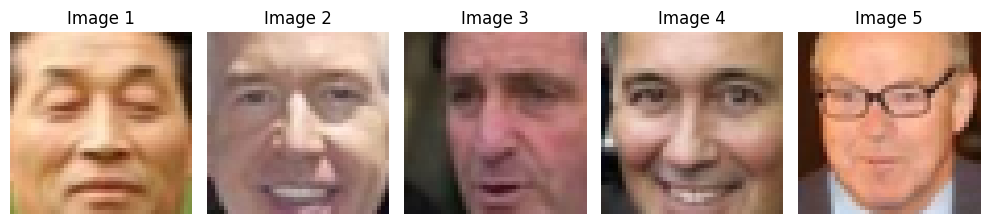

In [17]:
batch_images, _ = next(iter(train_loader))  # Автоэнкодер возвращает (input, target) — берем только input

# Создаем фигуру с 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

# Перебираем первые 5 картинок из батча
for i in range(5):
    single_image = batch_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    # Отображаем изображение
    axes[i].imshow(image_np)
    axes[i].axis('off')  # Отключаем оси
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



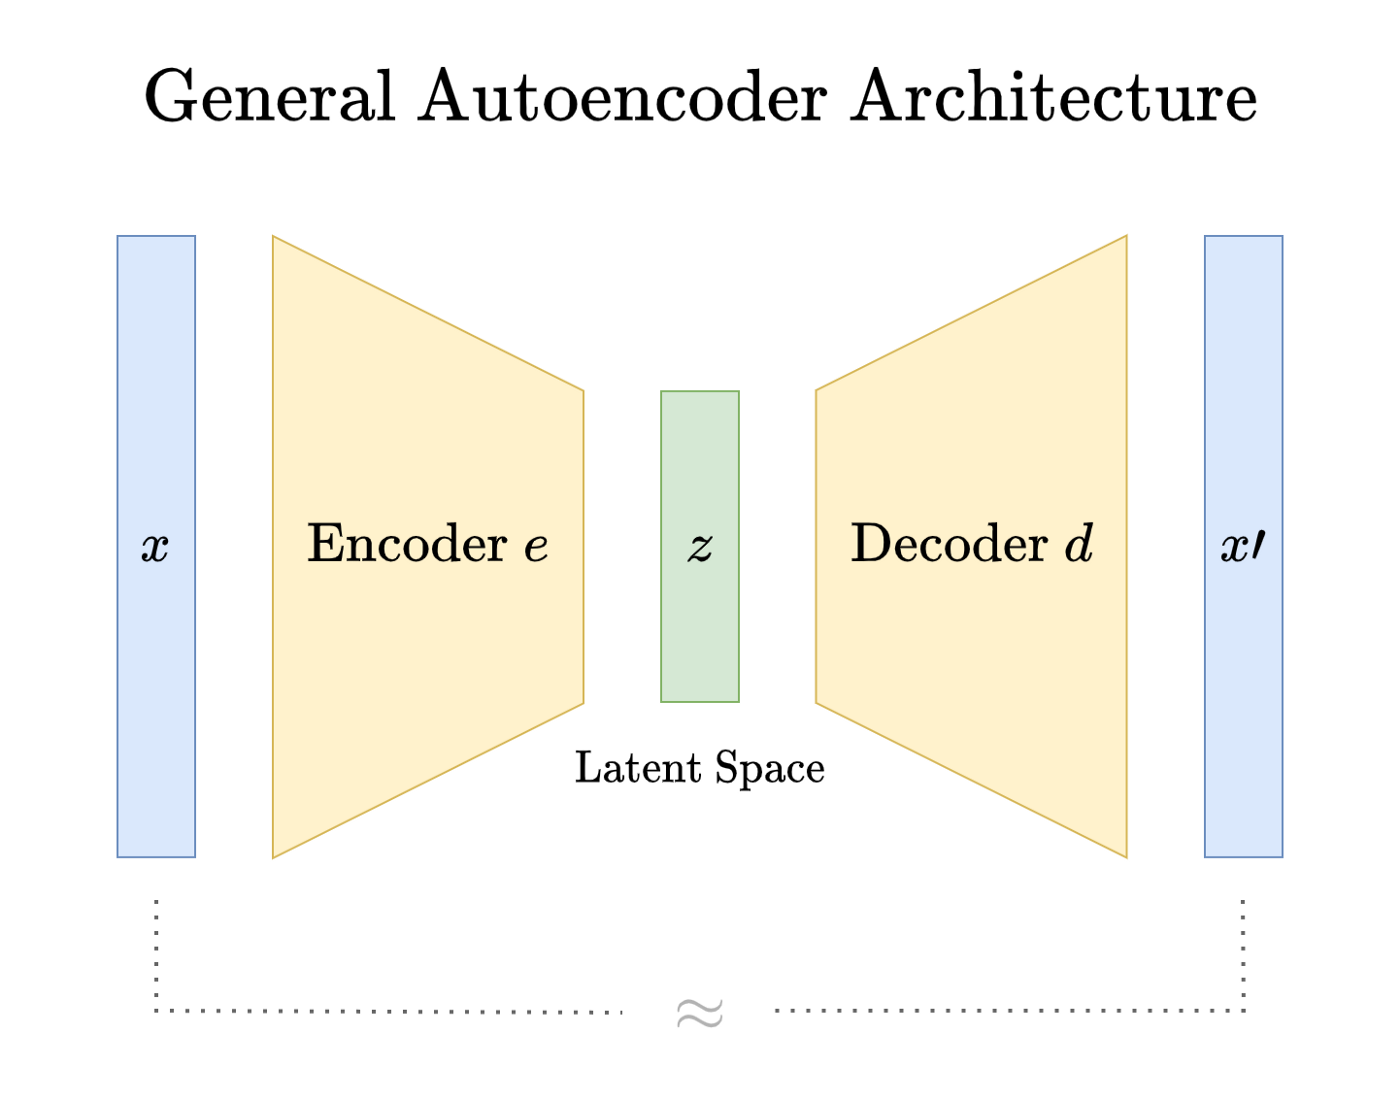

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [31]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(6*6*64, 128)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 6*6*64),
            nn.ReLU(),
            nn.Unflatten(1, (64, 6, 6)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=2),
            nn.AdaptiveAvgPool2d((44, 44)),  # Принудительно устанавливаем нужный размер
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code

In [59]:
model0=Autoencoder()
print(model0)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2304, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=2304, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 6, 6))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2))
    (8): AdaptiveAvgPool2d(output_size=(44, 44))
    (9): Sigmoid()
  )
)


## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [ ]:
# Инициализация модели и оптимизатора
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)
criterion = nn.MSELoss()  # Для RGB можно попробовать nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Функция для обучения модели
def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (images, _) in enumerate(train_loader):
            # Перемещаем изображения на устройство (CPU/GPU)
            images = images.to(device)
            
            # Обнуляем градиенты
            optimizer.zero_grad()
            
            # Прямой проход
            reconstructions, latent = model(images)
            
            # Вычисляем функцию потерь
            loss = criterion(reconstructions, images)
            
            # Обратное распространение ошибки
            loss.backward()
            
            # Оптимизация весов
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # Выводим статус каждые 100 батчей
            if (batch_idx + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], '
                      f'Batch [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')
        
        # Средняя потеря за эпоху
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')
    
    return train_losses

Epoch [1/50], Batch [100/165], Loss: 0.0174
Epoch [1/50], Average Loss: 0.0232
Epoch [2/50], Batch [100/165], Loss: 0.0095
Epoch [2/50], Average Loss: 0.0097
Epoch [3/50], Batch [100/165], Loss: 0.0071
Epoch [3/50], Average Loss: 0.0074
Epoch [4/50], Batch [100/165], Loss: 0.0059
Epoch [4/50], Average Loss: 0.0062
Epoch [5/50], Batch [100/165], Loss: 0.0051
Epoch [5/50], Average Loss: 0.0054
Epoch [6/50], Batch [100/165], Loss: 0.0046
Epoch [6/50], Average Loss: 0.0049
Epoch [7/50], Batch [100/165], Loss: 0.0044
Epoch [7/50], Average Loss: 0.0045
Epoch [8/50], Batch [100/165], Loss: 0.0040
Epoch [8/50], Average Loss: 0.0042
Epoch [9/50], Batch [100/165], Loss: 0.0041
Epoch [9/50], Average Loss: 0.0040
Epoch [10/50], Batch [100/165], Loss: 0.0035
Epoch [10/50], Average Loss: 0.0037
Epoch [11/50], Batch [100/165], Loss: 0.0034
Epoch [11/50], Average Loss: 0.0036
Epoch [12/50], Batch [100/165], Loss: 0.0032
Epoch [12/50], Average Loss: 0.0034
Epoch [13/50], Batch [100/165], Loss: 0.0032
E

In [ ]:
# Пример использования функции обучения
num_epochs = 50
train_losses = train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device)

1 Этап обучения

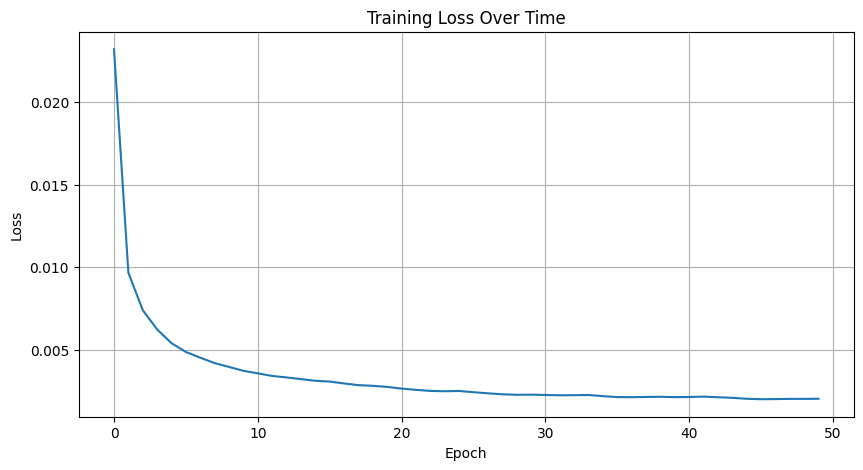

In [ ]:

# Визуализация процесса обучения
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [60]:
torch.save(model, 'autoencoder_v1.pth')

> Для обучения достаточно около 20 эпох

In [ ]:

# Функция для визуализации результатов
def visualize_reconstruction(model, test_loader, device, num_images=5):
    model.eval()
    with torch.no_grad():
        # Получаем batch изображений
        images, _ = next(iter(test_loader))
        images = images[:num_images].to(device)
        
        # Получаем реконструкции
        reconstructions, _ = model(images)
        
        # Переносим тензоры на CPU и конвертируем в numpy
        images = images.cpu().numpy()
        reconstructions = reconstructions.cpu().numpy()
        
        # Визуализируем результаты
        plt.figure(figsize=(12, 4))
        for i in range(num_images):
            # Оригинальное изображение
            plt.subplot(2, num_images, i + 1)
            plt.imshow(np.transpose(images[i], (1, 2, 0)))
            plt.title('Original')
            plt.axis('off')
            
            # Реконструкция
            plt.subplot(2, num_images, i + num_images + 1)
            plt.imshow(np.transpose(reconstructions[i], (1, 2, 0)))
            plt.title('Reconstructed')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()


Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

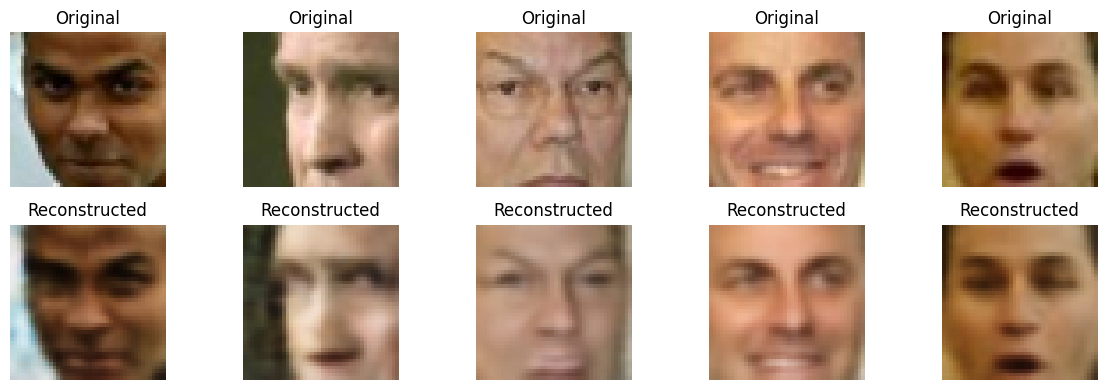

In [ ]:
# Пример использования функции визуализации
visualize_reconstruction(model, test_loader, device)

Что вы можете сказать про результат?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [69]:
# Функция для получения статистик латентного пространства
def get_latent_stats(model, dataloader, device, num_samples=1000):
    model.eval()
    latent_vectors = []
    
    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i * images.shape[0] >= num_samples:
                break
            images = images.to(device)
            _, latent = model(images)
            latent_vectors.append(latent.cpu().numpy())
    
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    mean = np.mean(latent_vectors, axis=0)
    std = np.std(latent_vectors, axis=0)
    
    return mean, std

# Функция для генерации новых изображений
def generate_images(model, num_images, latent_mean, latent_std, device):
    model.eval()
    # Генерируем случайные векторы с учетом статистик реальных данных
    z = np.random.normal(latent_mean, latent_std, (num_images, 128))
    
    with torch.no_grad():
        # Преобразуем в тензор и отправляем на устройство
        z = torch.FloatTensor(z).to(device)
        # Пропускаем через декодер
        generated_images, _ = model.decoder(z), None
    
    return generated_images

# Функция для визуализации сгенерированных изображений
def visualize_generated(images, num_rows=5, num_cols=5):
    plt.figure(figsize=(8, 8))
    for i in range(min(num_rows * num_cols, len(images))):
        plt.subplot(num_rows, num_cols, i + 1)
        # Преобразуем изображение для отображения
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


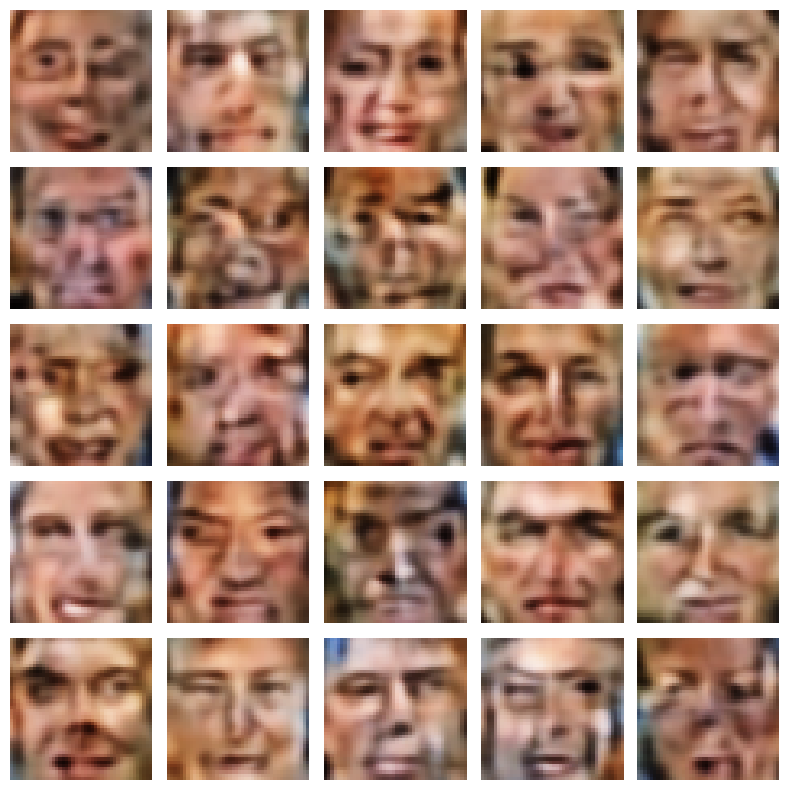

In [70]:

# Получаем статистики латентного пространства
latent_mean, latent_std = get_latent_stats(model, train_loader, device)

# Генерируем новые изображения
num_images = 25  # 5x5 сетка
generated_images = generate_images(model, num_images, latent_mean, latent_std, device)

# Визуализируем результаты
visualize_generated(generated_images)


In [64]:

# Пример интерполяции между двумя точками в латентном пространстве
def interpolate_latent(model, z1, z2, num_steps=10, device='cuda'):
    # Создаем промежуточные точки между z1 и z2
    alphas = np.linspace(0, 1, num_steps)
    interpolated_images = []
    
    with torch.no_grad():
        for alpha in alphas:
            # Линейная интерполяция
            z = torch.FloatTensor(z1 * (1 - alpha) + z2 * alpha).to(device)
            # Генерируем изображение
            image, _ = model.decoder(z.unsqueeze(0)), None
            interpolated_images.append(image[0])
    
    return torch.stack(interpolated_images)

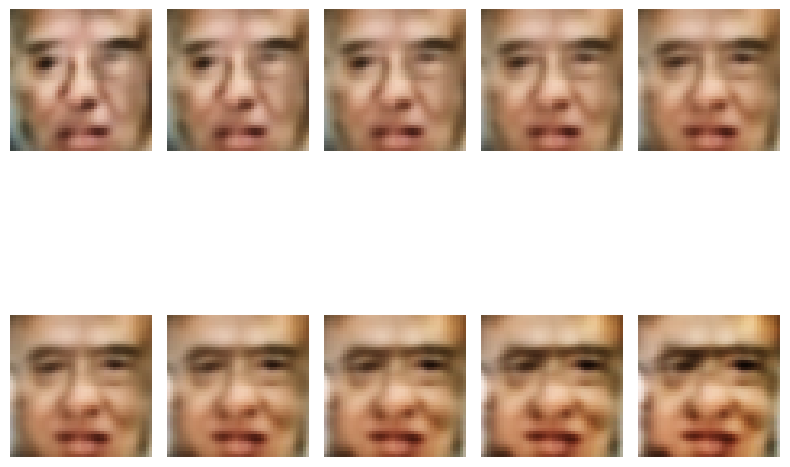

In [71]:

# Пример использования интерполяции
# Генерируем две случайные точки
z1 = np.random.normal(latent_mean, latent_std, (128,))
z2 = np.random.normal(latent_mean, latent_std, (128,))

# Получаем промежуточные изображения
interpolated = interpolate_latent(model, z1, z2, num_steps=10, device=device)

# Визуализируем интерполяцию
visualize_generated(interpolated, num_rows=2, num_cols=5)

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [ ]:
< тут
Ваш
код: выведите
первые
Х
картинок
и
их
реконструкций
из
val
выборки
на
экран >

In [45]:
attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa

In [53]:
attrs.Smiling.info()

<class 'pandas.core.series.Series'>
RangeIndex: 13143 entries, 0 to 13142
Series name: Smiling
Non-Null Count  Dtype 
--------------  ----- 
13143 non-null  object
dtypes: object(1)
memory usage: 102.8+ KB


In [54]:
attrs['Smiling'] = attrs['Smiling'].astype(float)

In [55]:
attrs.Smiling.describe()

count    13143.000000
mean        -0.150700
std          1.127722
min         -2.686594
25%         -1.065725
50%         -0.320783
75%          0.766401
max          2.839994
Name: Smiling, dtype: float64

In [78]:
attrs.loc[attrs.Smiling > 2, 'Smiling'].count()

342

In [84]:
idx_smiling=attrs.loc[attrs.Smiling > 2, 'Smiling'][:5].index.to_list()

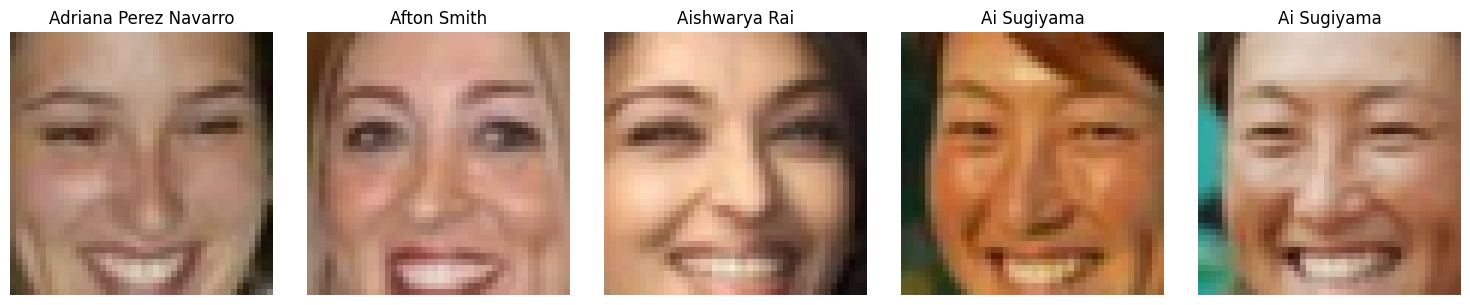

In [89]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

In [95]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

def get_smile_vectors(model, images, attrs, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Вычисляет вектор улыбки на основе латентных представлений изображений
    
    Args:
        model: обученная модель автоэнкодера
        images: numpy array изображений формата (N, H, W, C)
        attrs: pandas DataFrame с атрибутами
        device: устройство для вычислений
    
    Returns:
        smile_vector: вектор улыбки (разность между средними векторами)
        smiling_indices: индексы улыбающихся людей
        non_smiling_indices: индексы не улыбающихся людей
    """
    # 1. Выбираем индексы улыбающихся и не улыбающихся людей
    smiling_indices = attrs.loc[attrs.Smiling > 2, 'Smiling'][:15].index.to_list()
    non_smiling_indices = attrs.loc[attrs.Smiling < -2, 'Smiling'][:15].index.to_list()
    
    # Преобразуем изображения в тензоры и меняем порядок размерностей NHWC -> NCHW
    smiling_images = torch.FloatTensor(images[smiling_indices]).permute(0, 3, 1, 2) / 255.0
    non_smiling_images = torch.FloatTensor(images[non_smiling_indices]).permute(0, 3, 1, 2) / 255.0
    
    # Перемещаем на нужное устройство
    model = model.to(device)
    smiling_images = smiling_images.to(device)
    non_smiling_images = non_smiling_images.to(device)
    
    # 2. Получаем латентные векторы
    model.eval()
    with torch.no_grad():
        # Для улыбающихся
        _, smiling_latent = model(smiling_images)
        # Для не улыбающихся
        _, non_smiling_latent = model(non_smiling_images)
    
    # 3. Вычисляем средние векторы и их разность
    mean_smiling = torch.mean(smiling_latent, dim=0)
    mean_non_smiling = torch.mean(non_smiling_latent, dim=0)
    smile_vector = mean_smiling - mean_non_smiling
    
    return smile_vector, smiling_indices, non_smiling_indices

def add_smile(model, image, smile_vector, alpha=1.0, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Добавляет улыбку к изображению
    
    Args:
        model: обученная модель автоэнкодера
        image: исходное изображение (numpy array формата H x W x C)
        smile_vector: вектор улыбки
        alpha: коэффициент интенсивности улыбки
        device: устройство для вычислений
    
    Returns:
        numpy array: изображение с добавленной улыбкой
    """
    # Преобразуем изображение в тензор и меняем порядок размерностей HWC -> CHW
    image_tensor = torch.FloatTensor(image).unsqueeze(0).permute(0, 3, 1, 2) / 255.0
    image_tensor = image_tensor.to(device)
    model = model.to(device)
    smile_vector = smile_vector.to(device)
    
    # Получаем латентный вектор изображения
    model.eval()
    with torch.no_grad():
        _, latent = model(image_tensor)
        # Добавляем вектор улыбки
        new_latent = latent + alpha * smile_vector
        # Декодируем обратно в изображение
        generated_image, _ = model.decoder(new_latent)
    
    # Преобразуем обратно в numpy array и меняем порядок размерностей обратно CHW -> HWC
    result = generated_image.cpu().squeeze(0).permute(1, 2, 0).numpy()
    result = np.clip(result * 255, 0, 255).astype(np.uint8)
    
    return result

def visualize_smile_transformation(model, images, attrs, n_samples=5):
    """
    Визуализирует процесс добавления улыбки к изображениям
    
    Args:
        model: обученная модель автоэнкодера
        images: numpy array изображений
        attrs: pandas DataFrame с атрибутами
        n_samples: количество примеров для визуализации
    """
    import matplotlib.pyplot as plt
    
    # Получаем вектор улыбки
    smile_vector, _, _ = get_smile_vectors(model, images, attrs)
    
    # Выбираем несколько не улыбающихся людей
    non_smiling_indices = attrs.loc[attrs.Smiling < -2, 'Smiling'][:n_samples].index.to_list()
    
    # Создаем сетку изображений
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    
    for i, idx in enumerate(non_smiling_indices):
        # Исходное изображение
        axes[i, 0].imshow(images[idx])
        axes[i, 0].set_title('Оригинал')
        axes[i, 0].axis('off')
        
        # Изображение с небольшой улыбкой
        with_smile_05 = add_smile(model, images[idx], smile_vector, alpha=0.5)
        axes[i, 1].imshow(with_smile_05)
        axes[i, 1].set_title('Улыбка (α=0.5)')
        axes[i, 1].axis('off')
        
        # Изображение с сильной улыбкой
        with_smile_10 = add_smile(model, images[idx], smile_vector, alpha=1.0)
        axes[i, 2].imshow(with_smile_10)
        axes[i, 2].set_title('Улыбка (α=1.0)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show() 

In [96]:
get_smile_vectors(model, images, attrs)

(tensor([ 0.9378, -0.6458,  0.2769,  0.0086, -3.1229,  1.5425, -0.2667,  0.4982,
         -0.3673, -0.4089,  0.3578,  0.4739, -0.3748,  0.9128, -0.7967, -0.0442,
         -0.5772, -0.3083, -0.7115,  0.4297, -0.8481,  0.4828,  0.1233, -0.4812,
         -0.6525,  0.2496, -0.6324,  1.0445, -0.3125, -0.6450,  1.8685,  0.3275,
         -1.4849, -0.4363, -0.2690,  0.4346,  0.2255,  0.2176,  0.4833, -0.4123,
         -0.7307, -0.7105,  0.6863, -0.7032, -0.6304,  0.2464, -0.3675,  0.2170,
         -0.3204, -1.1139, -0.0440,  0.4777, -0.1510,  0.1907,  0.0884,  0.4492,
         -0.8255, -1.3754,  0.0496,  0.6866,  1.1367,  0.9467, -0.3579, -0.4836,
          0.6664, -0.2176,  0.7842, -0.5909,  0.7156, -1.4023, -0.7005,  0.5280,
         -1.2583, -0.4220,  0.4883,  0.0407,  2.5829, -0.6703,  0.2705,  0.1287,
          0.4855,  0.1113,  0.2405, -0.0077, -0.6916,  0.8317,  1.1392,  0.7305,
          0.4330,  0.6093, -0.6571,  0.8506, -0.0782,  0.1894, -1.2740, -1.0179,
         -0.0423,  0.3638, -

Количество улыбающихся людей: 15
Количество не улыбающихся людей: 15
Размерность вектора улыбки: torch.Size([128])
Ошибка при добавлении улыбки к одному изображению: not enough values to unpack (expected 2, got 1)

Визуализация трансформации для 5 изображений:
Ошибка при визуализации нескольких примеров: not enough values to unpack (expected 2, got 1)


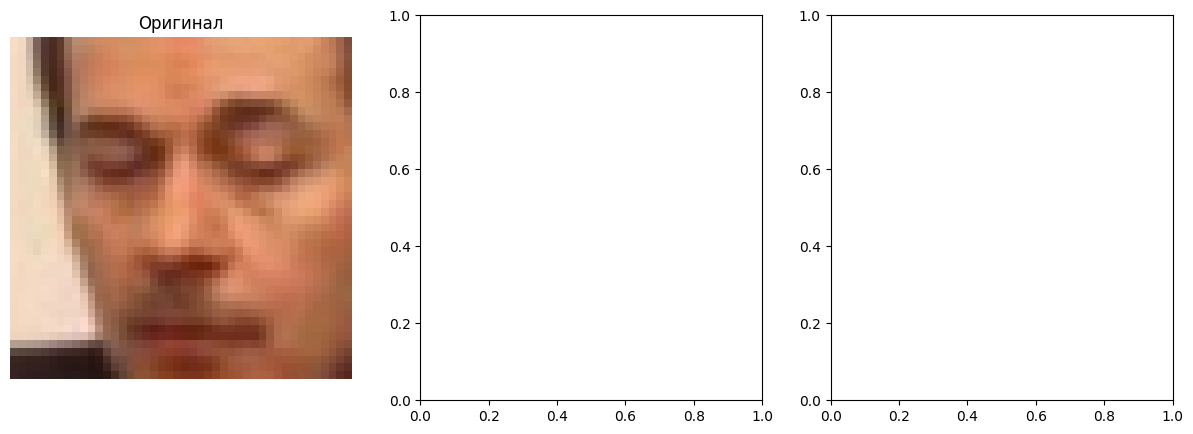

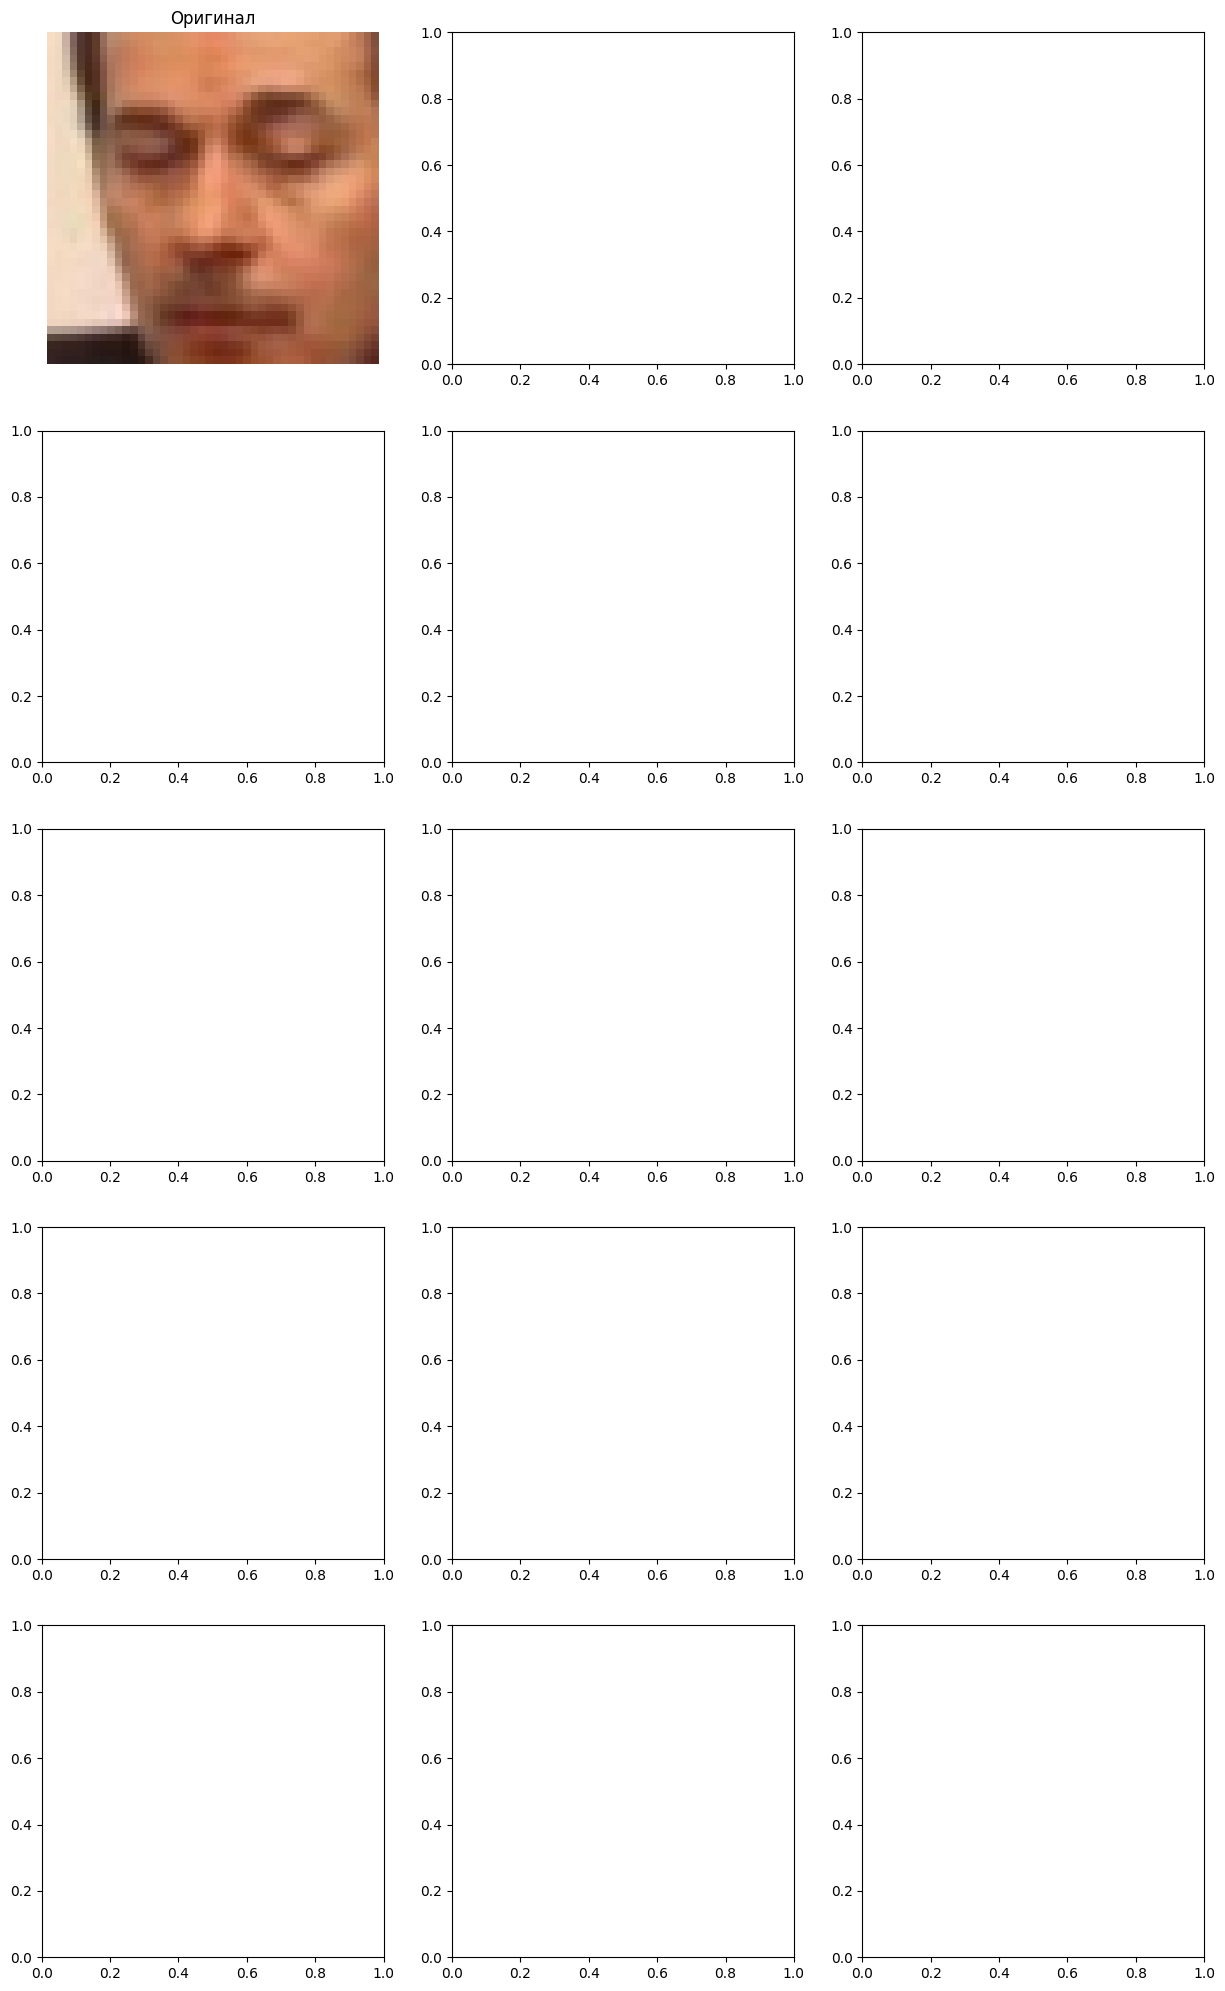

In [97]:
# Получение вектора улыбки
try:
    smile_vector, smiling_indices, non_smiling_indices = get_smile_vectors(model, images, attrs)
    print(f"Количество улыбающихся людей: {len(smiling_indices)}")
    print(f"Количество не улыбающихся людей: {len(non_smiling_indices)}")
    print(f"Размерность вектора улыбки: {smile_vector.shape}")
except Exception as e:
    print(f"Ошибка при получении вектора улыбки: {e}")

# Пример добавления улыбки к одному изображению
try:
    # Выбираем индекс не улыбающегося человека
    test_idx = non_smiling_indices[0]
    
    # Создаем сетку для визуализации
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Исходное изображение
    axes[0].imshow(images[test_idx])
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    # Добавляем улыбку с разной интенсивностью
    for i, alpha in enumerate([0.5, 1.0]):
        result = add_smile(model, images[test_idx], smile_vector, alpha=alpha)
        axes[i+1].imshow(result)
        axes[i+1].set_title(f'Улыбка (α={alpha})')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при добавлении улыбки к одному изображению: {e}")

# Визуализация нескольких примеров
try:
    print("\nВизуализация трансформации для 5 изображений:")
    visualize_smile_transformation(model, images, attrs, n_samples=5)
except Exception as e:
    print(f"Ошибка при визуализации нескольких примеров: {e}")

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        < определите
        архитектуры
        encoder
        и
        decoder
        помните, у
        encoder
        должны
        быть
        два
        "хвоста",
        т.е.encoder
        должен
        кодировать
        картинку
        в
        2
        переменные - - mu
        и
        logsigma >

    def encode(self, x):
        < реализуйте
        forward
        проход
        энкодера
        в
        качестве
        ваозвращаемых
        переменных - - mu
        и
        logsigma >

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            < засемплируйте
            латентный
            вектор
            из
            нормального
            распределения
            с
            параметрами
            mu
            и
            sigma >
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        < реализуйте
        forward
        проход
        декодера
        в
        качестве
        возвращаемой
        переменной - - reconstruction >

        return reconstruction

    def forward(self, x):
        < используя
        encode
        и
        decode, реализуйте
        forward
        проход
        автоэнкодера
        в
        качестве
        ваозвращаемых
        переменных - - mu, logsigma
        и
        reconstruction >
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = < напишите
    код
    для
    KL - дивергенции, пользуясь
    формулой
    выше >
    return


def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = < binary
    cross - entropy >
    return loss(reconstruction, x)


def loss_vae(x, mu, logsigma, reconstruction):
    return < соедините
    тут
    две
    компоненты
    лосса.Mind
    the
    sign!>

И обучим модель:

In [ ]:
criterion = loss_vae

autoencoder = VAE()

optimizer = < Ваш
любимый
оптимизатор >

In [ ]:
< обучите
модель
на
датасете
MNIST >

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

In [ ]:
< тут
Ваш
код: выведите
первые
Х
картинок
и
их
реконструкций
из
val
выборки
на
экран >

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [ ]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
z = np.array([np.random.normal(0, 1, 100) for i in range(10)])
output = < скормите
z
декодеру >
< выведите
тут
полученные
картинки >

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [ ]:
< ваш
код
получения
латентных
представлений, применения
TSNE
и
визуализации >

Что вы думаете о виде латентного представления?

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
class CVAE(nn.Module):
    def __init__(self):

    # <определите архитектуры encoder и decoder
    # помните, у encoder должны быть два "хвоста",
    # т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>

    def encode(self, x, class_num):
        # <реализуйте forward проход энкодера
        # в качестве возвращаемых переменных -- mu, logsigma и класс картинки>

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
        # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, class_num):
        # реализуйте forward проход декодера
        # в качестве возвращаемой переменной -- reconstruction

        return reconstruction

    def forward(self, x):
        # используя encode и decode, реализуйте forward проход автоэнкодера
        # в качестве ваозвращаемых переменных -- mu, logsigma и reconstruction
        return mu, logsigma, reconstruction

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [ ]:
< тут
нужно
научиться
сэмплировать
из
декодера
цифры
определенного
класса >

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [ ]:
< ваш
код
получения
латентных
представлений, применения
TSNE
и
визуализации >

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

# BONUS 1: Denoising (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
< тут
ваш
код
обучения
автоэнкодера
на
зашумленных
картинках.Не
забудьте
разбить
на
train / test!>

In [ ]:
< тут
проверка, как
AE
убирает
шум
с
тестовых
картинок.Надеюсь, все
получилось =) >

# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = < поучите
латентные
представления
картинок
из
трейна >

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest

lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
    # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
    # прогоняет векторы через декодер и получает картинки ближайших людей

    code = < получение
    латентного
    представления
    image >

    (distances,), (idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

    return distances, X_train[idx]

In [ ]:
def show_similar(image):
    # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances, neighbors = get_similar(image, n_neighbors=11)

    plt.figure(figsize=[8, 6])
    plt.subplot(3, 4, 1)
    plt.imshow(image.cpu().numpy().transpose([1, 2, 0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3, 4, i + 2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1, 2, 0]))
        plt.title("Dist=%.3f" % distances[i])
    plt.show()

In [ ]:
< тут
выведите
самые
похожие
лица
к
какому - нибудь
лицу
из
тестовой
части
датасета >